# Kaggle Playground Series S6E5 — Predict F1 Pit Stops
### Author: Ruide Yin

## Stage 6: Post-processing & Submission

**Goal:** Load pipeline outputs, sanity-check predictions, and generate `submission.csv`.  
**Metric:** AUC-ROC  
**No training is performed in this notebook — load only.**

### 6.1 Imports

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

import joblib
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                              confusion_matrix, roc_curve, precision_recall_curve)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

from sklearn.calibration import calibration_curve

OUTPUT_DIR = "./outputs"

### 6.2 Load Test Data & Confirm ID Column

In [2]:
test = pd.read_csv(f"{OUTPUT_DIR}/test_fe.csv")
print(f"Test shape: {test.shape}")
print(f"Columns ({len(test.columns)}): {list(test.columns)}")
print(f"\nID column stats:")
print(f"  dtype:  {test['id'].dtype}")
print(f"  range:  {test['id'].min()} ~ {test['id'].max()}")
print(f"  nunique: {test['id'].nunique()}  (should == {len(test)})")
assert test["id"].nunique() == len(test), "ID column has duplicates!"

test_ids = test["id"]
test_ids.head(10)

Test shape: (188165, 46)
Columns (46): ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'TL_ratio_p50_CR', 'TL_ratio_p75_CR', 'TL_over_p75_CR', 'TL_ratio_p50_CY', 'TL_ratio_p75_CY', 'TL_over_p75_CY', 'TL_ratio_p50_CS', 'TL_ratio_p75_CS', 'TL_over_p75_CS', 'TL_ratio_p50_CD', 'TL_ratio_p75_CD', 'TL_over_p75_CD', 'Deg_per_lap', 'LapTime_Delta_clipped', 'LapTime_dev', 'RemainingProgress', 'is_last_10pct', 'is_last_5pct', 'is_first_5pct', 'is_last_stint', 'Compound_ord', 'Driver_te', 'Race_te', 'Driver_freq', 'Race_freq', 'Compound_x_TyreLife', 'Compound_x_CumDeg', 'RaceProgress_x_TyreLife', 'Position_x_LTDelta', 'LapTime_lag_diff', 'CumDeg_lag_diff']

ID column stats:
  dtype:  int64
  range:  439140 ~ 627304
  nunique: 188165  (should == 188165)


0    496081
1    476804
2    505009
3    475620
4    616284
5    520550
6    460984
7    476672
8    505845
9    573714
Name: id, dtype: int64

### 6.3 Load Ensemble Configuration

In [ ]:
with open(f"{OUTPUT_DIR}/ensemble_config.pkl", "rb") as f:
    ens_cfg = pickle.load(f)

print("=" * 60)
print("Pipeline Selected Ensemble")
print("=" * 60)
print(f"  Primary method:    {ens_cfg.get('primary_method', 'N/A')}")
print(f"  Primary AUC:       {ens_cfg.get('primary_auc', 'N/A')}")
print(f"  Alternate method:  {ens_cfg.get('alternate_method', 'N/A')}")
print(f"  Alternate AUC:     {ens_cfg.get('alternate_auc', 'N/A')}")
print(f"  Stack meta:        {ens_cfg.get('stack_meta', 'N/A')}")
print(f"\n  Base models in stack:")
for i, m in enumerate(ens_cfg.get("selected", [])):
    w = ens_cfg.get("weights", [None])[i] if ens_cfg.get("weights") else None
    w_str = f"  (WA weight={w:.4f})" if w is not None else ""
    print(f"    [{i+1}] {m}{w_str}")
print(f"\n  All candidates:")
for name, auc_ in ens_cfg.get('all_candidates_auc', {}).items():
    print(f"    {name:15s}  AUC = {auc_:.6f}")
print("=" * 60)

Pipeline Selected Ensemble
  Method:      Stacking
  Final AUC:   0.9500244059489253

  Selected models:
    [1] XGB_tuned  (weight=0.3619)
    [2] LGB_tuned  (weight=0.3517)
    [3] CAT_baseline  (weight=0.2865)


### 6.4 Load Final Test Predictions

In [ ]:
test_final = np.load(f"{OUTPUT_DIR}/test_final.npy")
test_final_alt = np.load(f"{OUTPUT_DIR}/test_final_alt.npy")
print(f"test_final     shape: {test_final.shape}, dtype: {test_final.dtype}")
print(f"test_final_alt shape: {test_final_alt.shape}, dtype: {test_final_alt.dtype}")

test_final shape: (188165,)
test_final dtype: float64


### 6.5 Load All Single-Model Predictions

In [ ]:
MODEL_NAMES = [
    "LGB_tuned", "XGB_tuned", "CAT_tuned",
]

preds = {}
for name in MODEL_NAMES:
    path = f"{OUTPUT_DIR}/test_{name}.npy"
    try:
        preds[name] = np.load(path)
        print(f"  {name:15s}  shape={preds[name].shape}")
    except FileNotFoundError:
        print(f"  {name:15s}  NOT FOUND — skipped")

# Load all 4 ensemble candidates
ENSEMBLE_NAMES = ["WeightedAvg", "Stacking", "RankAverage", "Hybrid"]
for tag in ENSEMBLE_NAMES:
    path = f"{OUTPUT_DIR}/test_{tag}.npy"
    try:
        preds[tag] = np.load(path)
        print(f"  {tag:15s}  shape={preds[tag].shape}")
    except FileNotFoundError:
        print(f"  {tag:15s}  NOT FOUND — skipped")

print(f"\nLoaded {len(preds)} prediction arrays in total.")

# ── Load OOF predictions & labels for evaluation ──
y = np.load(f"{OUTPUT_DIR}/y.npy")

oof_preds = {}
for name in MODEL_NAMES:
    path = f"{OUTPUT_DIR}/oof_{name}.npy"
    try:
        oof_preds[name] = np.load(path)
        print(f"  OOF {name:15s}  shape={oof_preds[name].shape}")
    except FileNotFoundError:
        print(f"  OOF {name:15s}  NOT FOUND")

# Load all 4 ensemble OOF predictions
for tag in ENSEMBLE_NAMES:
    path = f"{OUTPUT_DIR}/oof_{tag}.npy"
    try:
        oof_preds[tag] = np.load(path)
        print(f"  OOF {tag:15s}  shape={oof_preds[tag].shape}")
    except FileNotFoundError:
        print(f"  OOF {tag:15s}  NOT FOUND")

  LGB_tuned        shape=(188165,)
  XGB_tuned        shape=(188165,)
  CAT_baseline     shape=(188165,)
  ensemble_wa      shape=(188165,)
  ensemble_stack   shape=(188165,)

Loaded 5 prediction arrays in total.
  OOF LGB_tuned        shape=(439140,)
  OOF XGB_tuned        shape=(439140,)
  OOF CAT_baseline     shape=(439140,)
  OOF Ensemble_Stack   shape=(439140,)


### 6.6 Sanity Checks

#### 6.6.1 Basic Statistics & NaN / Range Check

In [6]:
TRAIN_POS_RATE = 0.199  # from EDA: ~19.9%

print(f"{'Source':<18s} {'Mean':>8s} {'Median':>8s} {'Min':>8s} {'Max':>8s} {'Std':>8s} {'NaN':>5s} {'OOB':>5s}")
print("-" * 80)

all_arrays = {"test_final": test_final, **preds}

for name, arr in all_arrays.items():
    n_nan = int(np.isnan(arr).sum())
    n_oob = int(((arr < 0) | (arr > 1)).sum()) - n_nan  # out-of-bound excluding NaN
    print(f"{name:<18s} {arr.mean():8.5f} {np.median(arr):8.5f} {arr.min():8.5f} {arr.max():8.5f} {arr.std():8.5f} {n_nan:5d} {n_oob:5d}")

print(f"\n{'Train pos rate':<18s} {TRAIN_POS_RATE:8.5f}")
print("\n[OK] If mean ≈ 0.199, predictions are well-calibrated.")
print("[OK] NaN = 0 and OOB = 0 for all sources → safe to submit.")

Source                 Mean   Median      Min      Max      Std   NaN   OOB
--------------------------------------------------------------------------------
test_final          0.19716  0.01621  0.01119  0.85625  0.29721     0     0
LGB_tuned           0.27715  0.05461  0.00000  0.99774  0.35676     0     0
XGB_tuned           0.27926  0.05908  0.00001  0.99768  0.35597     0     0
CAT_baseline        0.29204  0.07561  0.00000  0.99653  0.35696     0     0
ensemble_wa         0.28218  0.06271  0.00001  0.99708  0.35602     0     0
ensemble_stack      0.19716  0.01621  0.01119  0.85625  0.29721     0     0

Train pos rate      0.19900

[OK] If mean ≈ 0.199, predictions are well-calibrated.
[OK] NaN = 0 and OOB = 0 for all sources → safe to submit.


#### 6.6.2 Prediction Distribution Histogram

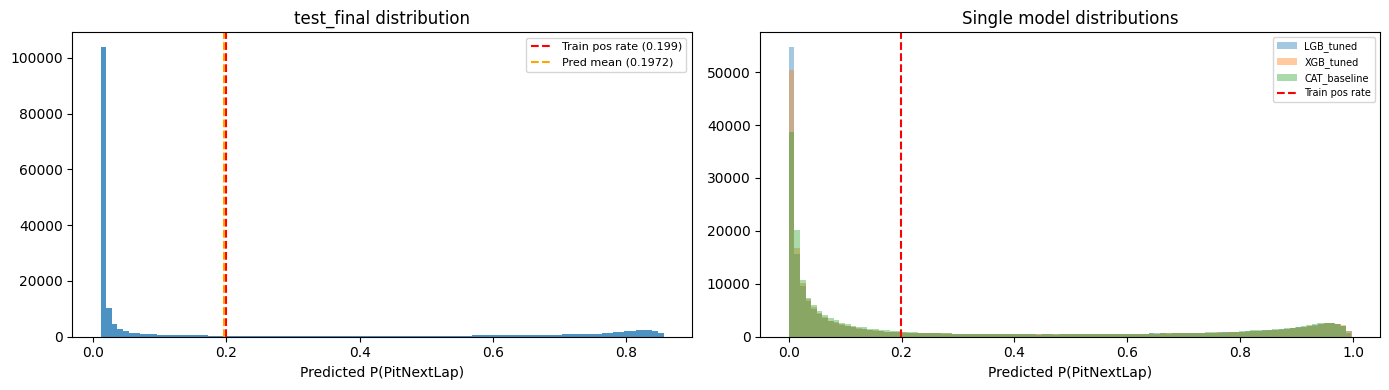

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: test_final
axes[0].hist(test_final, bins=100, edgecolor="none", alpha=0.8)
axes[0].axvline(TRAIN_POS_RATE, color="red", ls="--", label=f"Train pos rate ({TRAIN_POS_RATE})")
axes[0].axvline(test_final.mean(), color="orange", ls="--", label=f"Pred mean ({test_final.mean():.4f})")
axes[0].set_title("test_final distribution")
axes[0].set_xlabel("Predicted P(PitNextLap)")
axes[0].legend(fontsize=8)

# Right: all single models overlaid
for name, arr in preds.items():
    if name.startswith("ensemble"):
        continue
    axes[1].hist(arr, bins=100, alpha=0.4, label=name, edgecolor="none")
axes[1].axvline(TRAIN_POS_RATE, color="red", ls="--", label="Train pos rate")
axes[1].set_title("Single model distributions")
axes[1].set_xlabel("Predicted P(PitNextLap)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

#### 6.6.3 ROC Curves and PR Curves

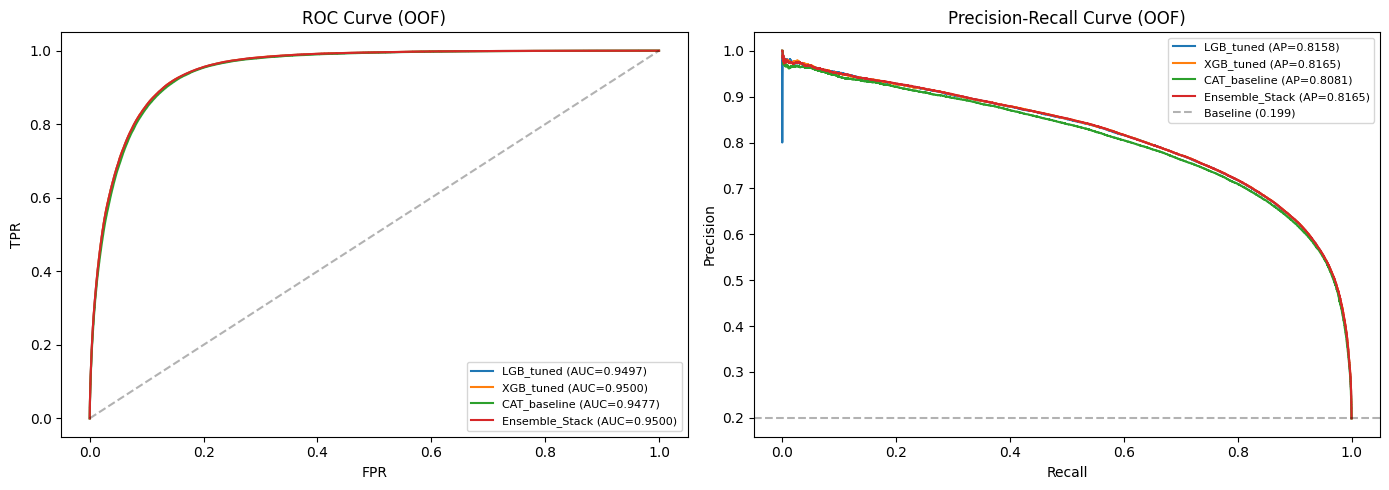

In [8]:
### 6.6.3 ROC Curve & PR Curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for name, oof in oof_preds.items():
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (OOF)')
axes[0].legend(fontsize=8)

# PR
for name, oof in oof_preds.items():
    prec, rec, _ = precision_recall_curve(y, oof)
    ap = average_precision_score(y, oof)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.4f})")
axes[1].axhline(y.mean(), color='k', ls='--', alpha=0.3, label=f"Baseline ({y.mean():.3f})")
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (OOF)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### 6.6.4 Confusion Matrix (threshold = 0.5)

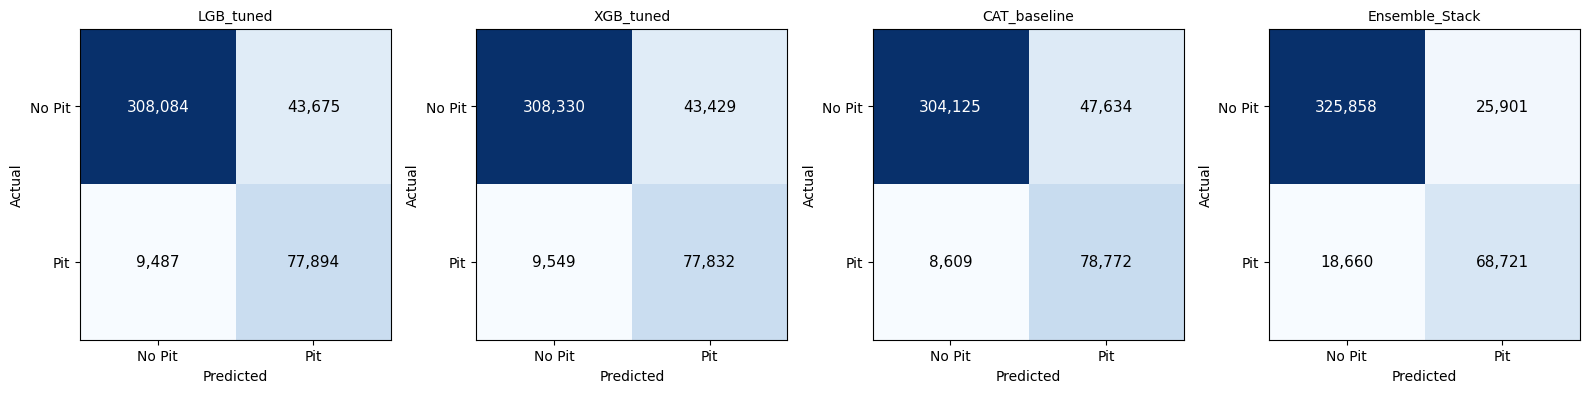

In [9]:
### 6.6.4 Confusion Matrix (threshold=0.5)

fig, axes = plt.subplots(1, len(oof_preds), figsize=(4*len(oof_preds), 4))
if len(oof_preds) == 1:
    axes = [axes]

for ax, (name, oof) in zip(axes, oof_preds.items()):
    cm = confusion_matrix(y, (oof >= 0.5).astype(int))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{name}", fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No Pit','Pit']); ax.set_yticklabels(['No Pit','Pit'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=11)

plt.tight_layout()
plt.show()

#### 6.6.5 Calibration Curve

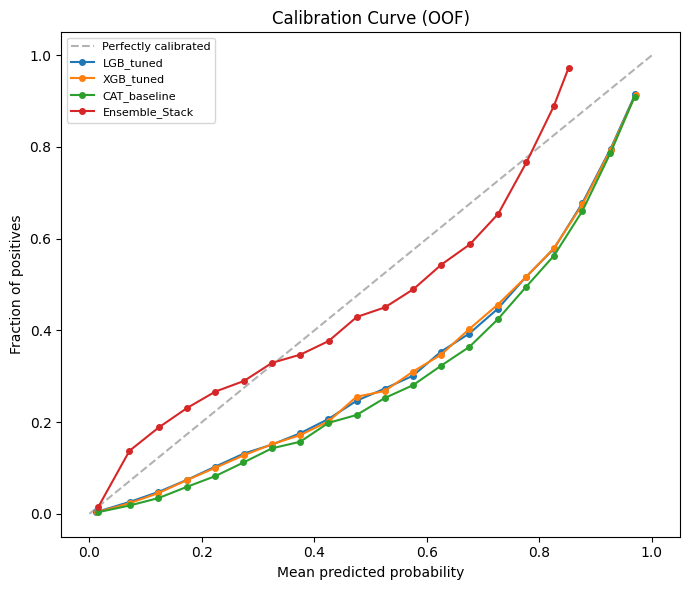

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfectly calibrated')

for name, oof in oof_preds.items():
    prob_true, prob_pred = calibration_curve(y, oof, n_bins=20, strategy='uniform')
    ax.plot(prob_pred, prob_true, marker='o', markersize=4, label=name)

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve (OOF)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### 6.6.6 Feature Importance and Train-Test Distribution Comparison

Top 8 features (rank aggregation across LGB/XGB/CAT):
  1. Year  (avg_rank=1.7)
  2. Stint  (avg_rank=2.0)
  3. Compound_x_TyreLife  (avg_rank=4.7)
  4. LapTime_Delta  (avg_rank=8.7)
  5. TyreLife  (avg_rank=9.0)
  6. Compound_ord  (avg_rank=9.0)
  7. LapTime_Delta_clipped  (avg_rank=9.3)
  8. Race_te  (avg_rank=10.0)


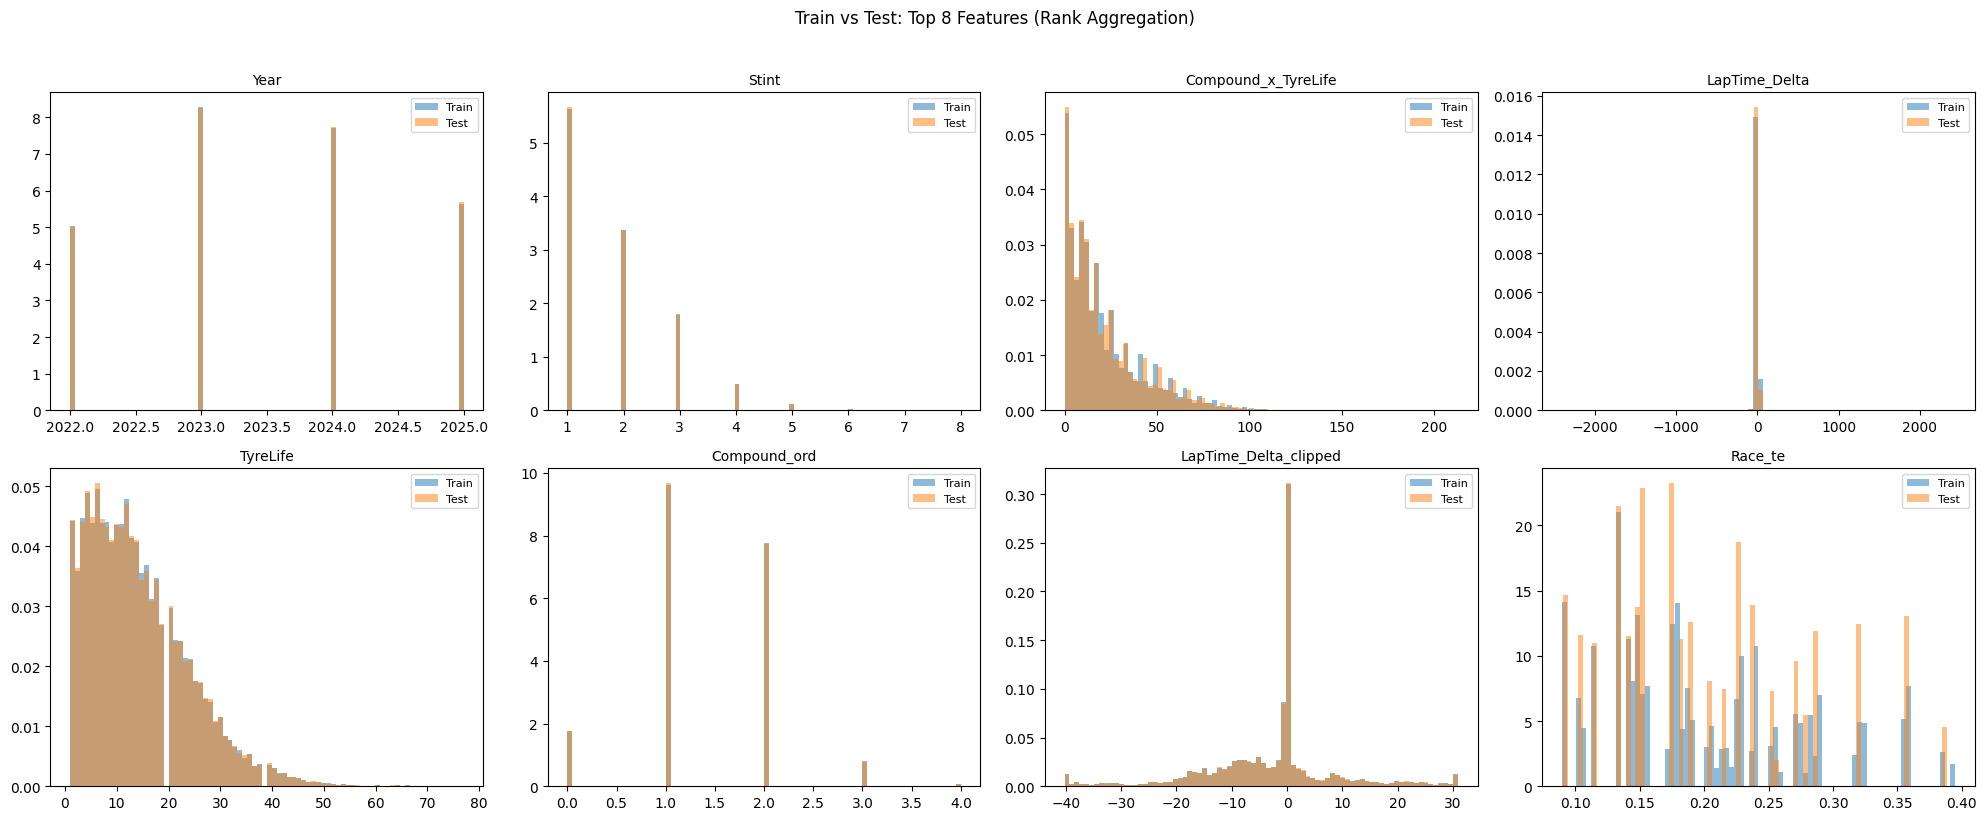

In [ ]:
import pickle as _pkl

# Load the same numeric matrix used during training (NaN preserved for GBDTs)
X_tr = np.load(f"{OUTPUT_DIR}/X.npy")
y_tr = np.load(f"{OUTPUT_DIR}/y.npy")
FEATURES = _pkl.load(open(f"{OUTPUT_DIR}/features_list.pkl", "rb"))

# Load best params (strip GPU device for portability)
def _safe_params(p):
    p = dict(p)
    p.pop('device', None)
    p.pop('task_type', None)
    return p

# ── LGB importance ──
lgb_params = _safe_params(joblib.load(f"{OUTPUT_DIR}/lgb_best_params.pkl"))
dtrain = lgb.Dataset(X_tr, y_tr, feature_name=FEATURES)
lgb_model = lgb.train({**lgb_params, 'objective': 'binary', 'metric': 'auc',
                       'verbosity': -1, 'n_jobs': -1},
                      dtrain, num_boost_round=100)
imp_lgb = pd.Series(lgb_model.feature_importance(importance_type='gain'), index=FEATURES)
top_lgb = set(imp_lgb.sort_values(ascending=False).head(12).index)

# ── XGB importance ──
xgb_params = _safe_params(joblib.load(f"{OUTPUT_DIR}/xgb_best_params.pkl"))
dmat = xgb.DMatrix(X_tr, y_tr, feature_names=FEATURES)
xgb_model = xgb.train({**xgb_params, 'objective': 'binary:logistic',
                       'eval_metric': 'auc', 'verbosity': 0},
                      dmat, num_boost_round=100)
imp_xgb_raw = xgb_model.get_score(importance_type='gain')
imp_xgb = pd.Series([imp_xgb_raw.get(f, 0.0) for f in FEATURES], index=FEATURES)
top_xgb = set(imp_xgb.sort_values(ascending=False).head(12).index)

# ── CatBoost importance (quick numeric-only refit for plotting only) ──
cat_model = CatBoostClassifier(iterations=100, verbose=0,
                                auto_class_weights='Balanced',
                                allow_writing_files=False)
cat_model.fit(np.nan_to_num(X_tr, nan=0.0), y_tr)
imp_cat = pd.Series(cat_model.get_feature_importance(), index=FEATURES)
top_cat = set(imp_cat.sort_values(ascending=False).head(12).index)

# ── Rank aggregation: average rank across 3 models, take top 8 ──
all_feats = top_lgb | top_xgb | top_cat
rank_lgb = imp_lgb.rank(ascending=False)
rank_xgb = imp_xgb.rank(ascending=False)
rank_cat = imp_cat.rank(ascending=False)

avg_rank = pd.DataFrame({
    'LGB_rank': rank_lgb,
    'XGB_rank': rank_xgb,
    'CAT_rank': rank_cat,
}).mean(axis=1)

avg_rank_filtered = avg_rank[avg_rank.index.isin(all_feats)]
top8 = avg_rank_filtered.sort_values().head(8).index.tolist()

print("Top 8 features (rank aggregation across LGB/XGB/CAT):")
for i, f in enumerate(top8):
    print(f"  {i+1}. {f}  (avg_rank={avg_rank[f]:.1f})")

# ── Plot ──
train_fe = pd.read_csv(f"{OUTPUT_DIR}/train_fe.csv")
test_fe = pd.read_csv(f"{OUTPUT_DIR}/test_fe.csv")

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()
for ax, feat in zip(axes, top8):
    if feat not in train_fe.columns or feat not in test_fe.columns:
        ax.set_title(f"{feat} (missing)", fontsize=10)
        continue
    ax.hist(train_fe[feat].dropna(), bins=80, alpha=0.5, label='Train',
            edgecolor='none', density=True)
    ax.hist(test_fe[feat].dropna(), bins=80, alpha=0.5, label='Test',
            edgecolor='none', density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Train vs Test: Top 8 Features (Rank Aggregation)', y=1.02)
plt.tight_layout()
plt.show()

del train_fe, test_fe, lgb_model, xgb_model, cat_model

### 6.7 Generate `submission.csv`

In [ ]:
# Primary submission
sub1 = pd.DataFrame({"id": test_ids, "PitNextLap": test_final})
assert len(sub1) == len(test)
assert sub1["PitNextLap"].isna().sum() == 0
assert sub1["PitNextLap"].between(0, 1).all()
sub1.to_csv(f"{OUTPUT_DIR}/submission.csv", index=False)

# Alternate submission
sub2 = pd.DataFrame({"id": test_ids, "PitNextLap": test_final_alt})
assert len(sub2) == len(test)
assert sub2["PitNextLap"].isna().sum() == 0
assert sub2["PitNextLap"].between(0, 1).all()
sub2.to_csv(f"{OUTPUT_DIR}/submission_alt.csv", index=False)

print(f"Primary   [{ens_cfg.get('primary_method', 'N/A')}]  AUC={ens_cfg.get('primary_auc', 0):.6f}")
print(f"  Saved:  {OUTPUT_DIR}/submission.csv")
print(f"  Rows:   {len(sub1)}, Mean: {sub1['PitNextLap'].mean():.5f}, "
      f"Median: {sub1['PitNextLap'].median():.5f}")
print()
print(f"Alternate [{ens_cfg.get('alternate_method', 'N/A')}]  AUC={ens_cfg.get('alternate_auc', 0):.6f}")
print(f"  Saved:  {OUTPUT_DIR}/submission_alt.csv")
print(f"  Rows:   {len(sub2)}, Mean: {sub2['PitNextLap'].mean():.5f}, "
      f"Median: {sub2['PitNextLap'].median():.5f}")

sub1.head(10)

Saved to ./outputs/submission.csv
  Rows:  188165
  Mean:  0.19716


,id,PitNextLap
0,496081,0.012696
1,476804,0.013639
2,505009,0.671011
3,475620,0.011847
4,616284,0.011589
5,520550,0.011593
6,460984,0.012257
7,476672,0.011828
8,505845,0.011799
9,573714,0.030071
